<a href="https://colab.research.google.com/github/hamnamuvees1720-oss/northstar-analytics/blob/main/notebooks/02_r_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



[1] "Libraries installed and loaded successfully!"
[1] "All files loaded successfully from local session storage!"
  mean_distance sd_distance mean_rating mean_cost total_overrides
1      13.90932    7.477907    3.864679  12.84129             921
  failure_rate_pct
1         13.89474


Loading required package: reshape2

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘reshape2’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘plyr’




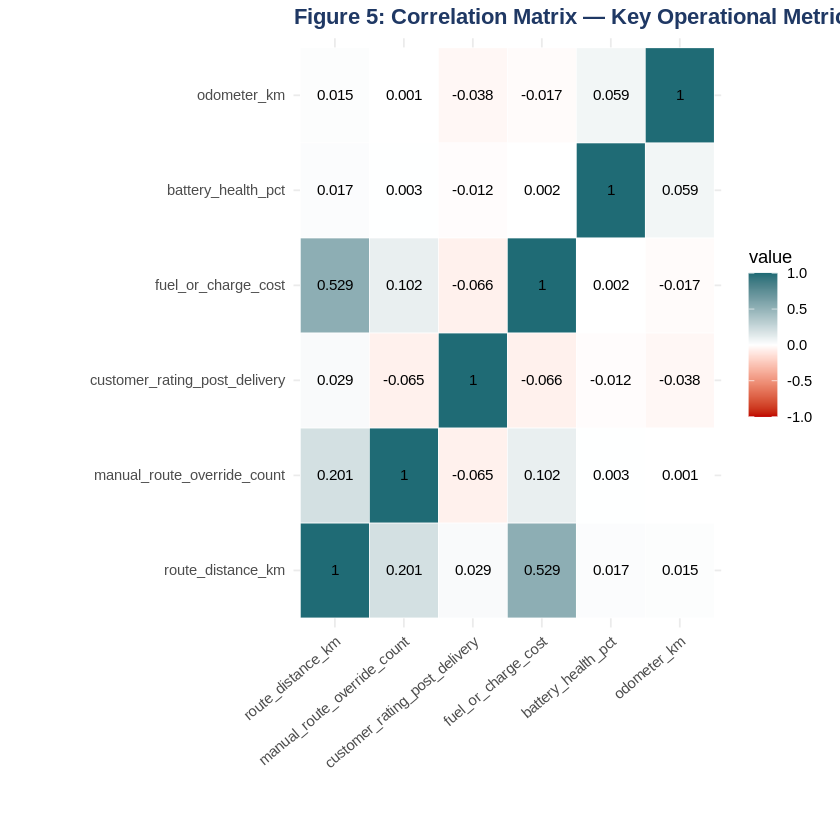

In [ ]:
# Combined installation for all necessary analytics tools
install.packages(c('dplyr', 'ggplot2', 'lubridate', 'scales', 'stringr', 'sqldf'))

# Load them all at once
library(dplyr)
library(ggplot2)
library(lubridate)
library(scales)
library(stringr)
library(sqldf)

print("Libraries installed and loaded successfully!")

# 2. Define the path (Since they are uploaded to the sidebar, use './')
path <- "./"

# 3. Load files
# Using stringsAsFactors=FALSE is a good practice for older R versions
orders     <- read.csv(paste0(path, "orders.csv"))
deliveries <- read.csv(paste0(path, "deliveries.csv"))
customers  <- read.csv(paste0(path, "customers.csv"))
drivers    <- read.csv(paste0(path, "drivers.csv"))
vehicles   <- read.csv(paste0(path, "vehicles.csv"))
hubs       <- read.csv(paste0(path, "hubs.csv"))
incidents  <- read.csv(paste0(path, "incidents.csv"))
complaints <- read.csv(paste0(path, "complaints.csv"))
app_events <- read.csv(paste0(path, "app_events.csv"))

print("All files loaded successfully from local session storage!")

# --- 1. Parse Datetimes and Engineer Features ---
# Use parse_date_time to handle multiple possible date formats automatically
deliveries$dispatch_time <- parse_date_time(
  deliveries$dispatch_time,
  orders = c("ymd HMS", "mdy HMS", "dmy HMS")
)

deliveries$delivery_completed_at <- parse_date_time(
  deliveries$delivery_completed_at,
  orders = c("ymd HMS", "mdy HMS", "dmy HMS")
)

complaints$created_at <- parse_date_time(
  complaints$created_at,
  orders = c("ymd HMS", "mdy HMS", "dmy HMS")
)

# Now that dates are valid, perform calculations
deliveries$duration_hrs <- as.numeric(difftime(
    deliveries$delivery_completed_at,
    deliveries$dispatch_time,
    units = 'hours'
))

# Financial and Status Engineering
deliveries$cost_per_km <- deliveries$fuel_or_charge_cost / deliveries$route_distance_km
deliveries$is_failed   <- as.integer(deliveries$delivery_status == 'Failed')

# --- 2. Summary Statistics ---
# Added na.rm = TRUE to failure_rate_pct to ensure the calculation doesn't break
summary_output <- deliveries %>% summarise(
  mean_distance    = mean(route_distance_km, na.rm = TRUE),
  sd_distance      = sd(route_distance_km, na.rm = TRUE),
  mean_rating      = mean(customer_rating_post_delivery, na.rm = TRUE),
  mean_cost        = mean(fuel_or_charge_cost, na.rm = TRUE),
  total_overrides  = sum(manual_route_override_count, na.rm = TRUE),
  failure_rate_pct = mean(is_failed, na.rm = TRUE) * 100
)

# Print the final result
print(summary_output)

# 1. Install and load reshape2
if (!require("reshape2")) install.packages("reshape2")
library(reshape2)

# 2. Create the joined dataframe (del_veh)
# We join 'deliveries' and 'vehicles' using the vehicle_id column
del_veh <- deliveries %>%
  left_join(vehicles, by = "vehicle_id")

# 3. Select numerical columns and remove NAs
num_data <- del_veh %>%
  select(route_distance_km, manual_route_override_count,
         customer_rating_post_delivery, fuel_or_charge_cost,
         battery_health_pct, odometer_km) %>%
  na.omit()

# 4. Create Correlation Matrix
cor_mat  <- round(cor(num_data), 3)
cor_melt <- melt(cor_mat)

# 5. Generate the Heatmap
ggplot(cor_melt, aes(Var1, Var2, fill=value)) +
  geom_tile(colour='white') +
  geom_text(aes(label=value), size=3.2) +
  # Gradient colors: Red for negative, Blue/Teal for positive
  scale_fill_gradient2(low='#C00000', high='#1F6B75', mid='white',
                       midpoint=0, limits=c(-1,1)) +
  labs(title='Figure 5: Correlation Matrix — Key Operational Metrics',
       x='', y='') +
  theme_minimal() +
  theme(axis.text.x=element_text(angle=40, hjust=1),
        plot.title=element_text(face='bold', color='#1F3864'))





